In [13]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from kuramoto.experiments import evaluate_metric_scores
from kuramoto.analysis import order_parameter
from kuramoto.config import (
    SimulationConfig,
    GridConfig,
    CouplingConfig,
    InitThetaConfig,
    InitOmegaConfig,
    KernelComponentConfig,
    build_simulation,
)
from kuramoto.network import plot_cortical_graph, create_cortical_graph

# -----------------------------------------------------------------------------
# Global notebook knobs
# -----------------------------------------------------------------------------

grid_shape = (12, 12)
T_END = 10.0
dt = 0.01

# Ensemble size per case
N_SEEDS = 5
N_SEEDS_SA1A = 20  # larger ensemble for seed-variance study
BASE_SEED = 42

# Lesion study hyperparameters
n_random_repeats = 10
lesion_fracs = np.arange(0, 0.3, 0.02)
lesion_strength = 1.0

# Integrated Gradients quadrature steps
N_IG_STEPS = 20

# Quick mode (set True to iterate faster)
QUICK_MODE = False
if QUICK_MODE:
    N_SEEDS = 1
    N_SEEDS_SA1A = 5
    lesion_fracs = np.arange(0, 0.3, 0.05)
    n_random_repeats = 3
    N_IG_STEPS = 10


# -----------------------------------------------------------------------------
# Case builders
# -----------------------------------------------------------------------------

def bottleneck_group_ids(grid_shape: tuple[int, int]) -> list[int]:
    n_rows, n_cols = grid_shape
    group_ids = np.zeros((n_rows, n_cols), dtype=int)
    group_ids[n_rows // 2 :, :] = 1  # bottom half
    group_ids[n_rows // 2 - 2 : n_rows // 2 + 2, n_cols // 2 - 2 : n_cols // 2 + 2] = 2  # central block
    return group_ids.ravel().tolist()


def random_group_ids(grid_shape: tuple[int, int], n_groups: int, rng: np.random.Generator) -> list[int]:
    n = int(np.prod(grid_shape))
    return rng.integers(0, n_groups, size=n, endpoint=False).astype(int).tolist()

def bottleneck_components_gaussian(k_factor: float = 1.0, seed: int = 42) -> list[KernelComponentConfig]:
    return [
        KernelComponentConfig(
            kernel="gaussian",
            base_strength=1.0*k_factor,
            kernel_params={"sigma": 1.0},
            radius=2.0,
            node_groups=[0],
            edge_mode="within",
        ),
        KernelComponentConfig(
            kernel="gaussian",
            base_strength=1.0*k_factor,
            kernel_params={"sigma": 1.0},
            radius=2.0,
            node_groups=[1],
            edge_mode="within",
        ),
        # bottleneck-like hub (group 2) coupling to/from everyone
        KernelComponentConfig(
            kernel="gaussian",
            base_strength=0.8*k_factor,
            kernel_params={"sigma": 4.0},
            radius=4.0,
            node_groups=[2],
            edge_mode="outgoing",
        ),
        KernelComponentConfig(
            kernel="gaussian",
            base_strength=0.8*k_factor,
            kernel_params={"sigma": 4.0},
            radius=4.0,
            node_groups=[2],
            edge_mode="incoming",
        ),
        # weak one-way coupling from group 1 to group 0
        KernelComponentConfig(
            kernel="gaussian",
            base_strength=0.2*k_factor,
            kernel_params={"sigma": 2.0},
            radius=2.0,
            node_groups=[1],
            edge_mode="custom",
            to_node_groups=[0],
        ),
        # Apply dropout to all groups
        KernelComponentConfig(
        kernel="dropout",
        kernel_params={"dropout_frac": 0.3},
        node_groups=[0,1,2],
        edge_mode="within",
        seed=seed,
        )
    ]

def random_group_components_mixed(n_groups: int = 6, k_factor: float = 1.0, seed: int = 42) -> list[KernelComponentConfig]:
    if n_groups % 2 == 1:
        raise ValueError("n_groups must be even")

    # Size bounds
    SIZE_LB = 0.5
    SIZE_UB = 2.0

    # Size factors
    size_factors = np.random.uniform(SIZE_LB, SIZE_UB, size=n_groups)

    comps: list[KernelComponentConfig] = []
    for g, sf in enumerate(size_factors):
        comps.append(
            KernelComponentConfig(
                kernel="gaussian",
                base_strength=1.0*k_factor,
                kernel_params={"sigma": 1.0*sf},
                radius=3.0*sf,
                node_groups=[g],
                edge_mode="within",
            )
        )

        mh_params = {"sigma_e": 1.0*sf, "sigma_i": 3.0*sf, "a_e": 1.0, "a_i": 0.8}
        comps.append(
            KernelComponentConfig(
                kernel="mexican_hat",
                base_strength=1.0*k_factor,
                kernel_params=mh_params,
                radius=4.0*sf,
                node_groups=[g+n_groups//2],
                edge_mode="within",
            )
        )

    # Apply dropout to all groups
    comps.append(KernelComponentConfig(
        kernel="dropout",
        kernel_params={"dropout_frac": 0.3},
        node_groups=list(range(n_groups)),
        edge_mode="within",
        seed=seed,
    ))

    return comps


def make_case_config(case_name: str, *, seed: int) -> tuple[SimulationConfig, dict]:
    rng = np.random.default_rng(seed)

    init_theta = InitThetaConfig(mode="uniform")
    init_omega = InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3)

    n_groups = 5

    if case_name == "bottleneck_gaussian":
        group_ids = bottleneck_group_ids(grid_shape)
        components = bottleneck_components_gaussian()
        label = "Bottleneck + Gaussian"

    elif case_name == "random_groups_mixed":
        group_ids = random_group_ids(grid_shape, n_groups=n_groups, rng=rng)
        components = random_group_components_mixed(n_groups=n_groups)
        label = "Random-groups(5) + Mixed"

    else:
        raise ValueError(f"Unknown case_name: {case_name!r}")

    cfg = SimulationConfig(
        grid=GridConfig(shape=grid_shape, periodic=False),
        coupling=CouplingConfig(
            kernel="gaussian",
            base_strength=1.0,
            radius=4.0,
            mode="spatial",
            components=components,
            group_ids=group_ids,
        ),
        initial_theta=init_theta,
        initial_omega=init_omega,
        seed=seed,
    )

    meta = {
        "case_name": case_name,
        "case_label": label,
        "seed": seed,
        "n_groups": n_groups,
    }
    return cfg, meta


# -----------------------------------------------------------------------------
# Aggregation utilities
# -----------------------------------------------------------------------------

def list_metrics(results_for_case: dict[int, dict]) -> list[str]:
    any_seed = next(iter(results_for_case.keys()))
    return sorted(results_for_case[any_seed].keys())

def aggregate_scores(results: dict[str, dict[int, dict]]) -> dict:
    out = {}
    for case_name, by_seed in results.items():
        metrics = list_metrics(by_seed)

        out[case_name] = {
            "metrics": metrics,
            "ABC_mean": {},
            "ABC_std": {},
            "AUC_ranked_mean": {},
            "AUC_ranked_std": {},
            "AUC_random_mean": {},
            "AUC_random_std": {},
            "R_avg_ranked_mean": {},
            "R_avg_ranked_std": {},
            "R_avg_random_mean": {},
            "R_avg_random_std": {},
        }

        for m in metrics:
            ABC = np.array([by_seed[s][m]["ABC"] for s in by_seed])
            AUC_r = np.array([by_seed[s][m]["AUC_ranked"] for s in by_seed])
            AUC_rand = np.array([by_seed[s][m]["AUC_random"] for s in by_seed])

            R_ranked = np.array([by_seed[s][m]["R_avg_ranked"] for s in by_seed], dtype=float)
            R_random = np.array([by_seed[s][m]["R_avg_random"] for s in by_seed], dtype=float)

            out[case_name]["ABC_mean"][m] = float(np.mean(ABC))
            out[case_name]["ABC_std"][m] = float(np.std(ABC))

            out[case_name]["AUC_ranked_mean"][m] = float(np.mean(AUC_r))
            out[case_name]["AUC_ranked_std"][m] = float(np.std(AUC_r))

            out[case_name]["AUC_random_mean"][m] = float(np.mean(AUC_rand))
            out[case_name]["AUC_random_std"][m] = float(np.std(AUC_rand))

            out[case_name]["R_avg_ranked_mean"][m] = np.mean(R_ranked, axis=0)
            out[case_name]["R_avg_ranked_std"][m] = np.std(R_ranked, axis=0)

            out[case_name]["R_avg_random_mean"][m] = np.mean(R_random, axis=0)
            out[case_name]["R_avg_random_std"][m] = np.std(R_random, axis=0)

    return out


def rank_correlation_matrix(agg: dict, case_names: list[str]) -> np.ndarray:
    """Pairwise Spearman rho of ABC vectors across conditions."""
    metrics = agg[case_names[0]]["metrics"]
    abc_vecs = np.array([[agg[c]["ABC_mean"][m] for m in metrics] for c in case_names])
    n = len(case_names)
    corr = np.ones((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            rho, _ = spearmanr(abc_vecs[i], abc_vecs[j])
            corr[i, j] = corr[j, i] = rho
    return corr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 0) Example networks

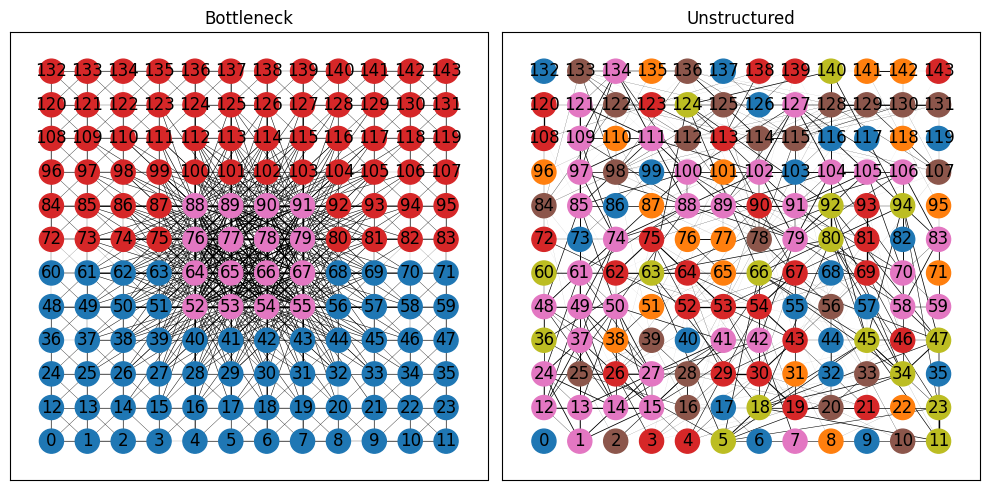

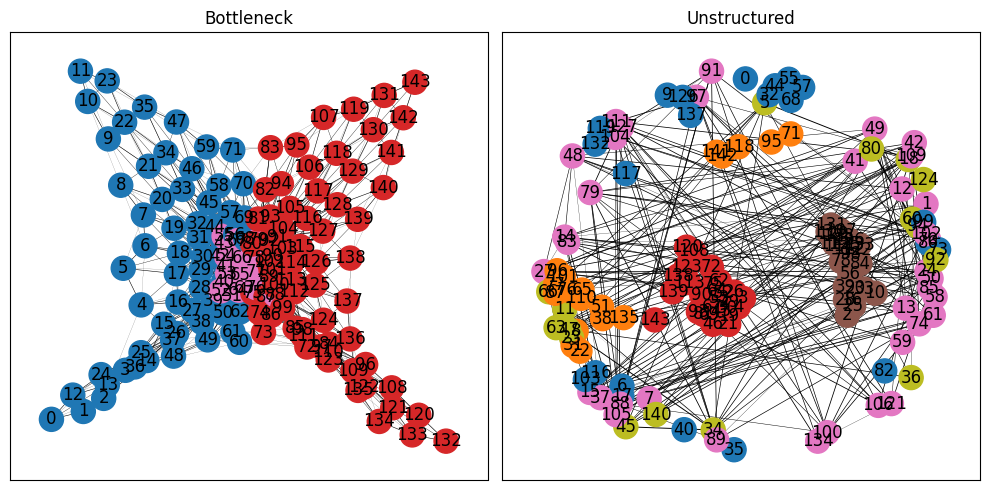

In [14]:
# Bottleneck case
cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(
        mode="spatial",
        components=bottleneck_components_gaussian(seed=42),
        group_ids=bottleneck_group_ids(grid_shape),
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=42,
)
sim_bottleneck = build_simulation(config=cfg, rng=np.random.default_rng(42))
G_bottleneck = create_cortical_graph(sim_bottleneck)

# Unstructured case
N_GROUPS = 6
cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(mode="full", 
                    components=random_group_components_mixed(n_groups=N_GROUPS, seed=42), 
                    group_ids=random_group_ids(grid_shape, n_groups=N_GROUPS, rng=np.random.default_rng(42)),
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=42,
)
sim_unstructured = build_simulation(config=cfg, rng=np.random.default_rng(42))
G_unstructured = create_cortical_graph(sim_unstructured)

# Show graph structure
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_cortical_graph(G_bottleneck, layout="grid", ax=axs[0])
axs[0].set_title("Bottleneck")
plot_cortical_graph(G_unstructured, layout="grid", ax=axs[1])
axs[1].set_title("Unstructured")
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_cortical_graph(G_bottleneck, layout="spring", ax=axs[0])
axs[0].set_title("Bottleneck")
plot_cortical_graph(G_unstructured, layout="spring", ax=axs[1])
axs[1].set_title("Unstructured")
plt.tight_layout()
plt.show()


In [94]:
from collections.abc import Mapping, Sequence

from kuramoto.plotting import plot_abc_spread_boxplot_h, plot_topk_abc_boxplots_h, METRIC_COLORS, color_for_metric

def plot_rt_traces_per_case(
    rt_by_case: Mapping[str, np.ndarray],
    dt: float,
    case_labels: Mapping[str, str],
    *,
    suptitle: str | None = None,
    ylim: tuple[float, float] = (0.0, 1.05),
    xlabel: str = "t",
    ylabel: str = "R(t)",
    figsize_per_col: float = 4.0,
    fig_height: float = 3.0,
    suptitle_y: float = 1.06,
):
    """One R(t) trace per case (e.g. one chosen seed per θ-sigma / ω-sigma)."""
    case_names = list(rt_by_case.keys())
    n = len(case_names)
    if n == 0:
        raise ValueError("rt_by_case must be non-empty")

    fig, axs = plt.subplots(1, n, figsize=(figsize_per_col * n, fig_height), constrained_layout=True)
    if n == 1:
        axs = np.array([axs])

    for ax, case_name in zip(axs.flat, case_names):
        Rt = np.asarray(rt_by_case[case_name])
        ax.plot(np.arange(len(Rt)) * dt, Rt)
        ax.set_title(case_labels[case_name])
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_ylim(*ylim)

    if suptitle is not None:
        fig.suptitle(suptitle, y=suptitle_y)
    return fig, axs


def plot_abc_mean_heatmap(
    agg: Mapping[str, Mapping],
    case_names: Sequence[str],
    metrics: Sequence[str],
    case_labels: Mapping[str, str],
    *,
    title: str,
    mean_key: str = "ABC_mean",
    cmap: str = "viridis",
    cbar_label: str = "ABC",
    fig_width_per_case: float = 1.2,
    fig_width_base: float = 6.0,
    fig_height_per_metric: float = 0.25,
    fig_height_base: float = 3.0,
    xtick_rotation: float = 30.0,
    ha: str = "right",
):
    """Rows = metrics, columns = cases; values from ``agg[case][mean_key][metric]``."""
    metrics = list(metrics)
    case_names = list(case_names)
    if not metrics or not case_names:
        raise ValueError("metrics and case_names must be non-empty")

    heat = np.array(
        [[agg[c][mean_key][m] for c in case_names] for m in metrics],
        dtype=float,
    )
    fig_w = fig_width_per_case * len(case_names) + fig_width_base
    fig_h = fig_height_per_metric * len(metrics) + fig_height_base
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), constrained_layout=True)
    im = ax.imshow(heat, aspect="auto", cmap=cmap)
    ax.set_xticks(np.arange(len(case_names)))
    ax.set_xticklabels([case_labels[c] for c in case_names], rotation=xtick_rotation, ha=ha)
    ax.set_yticks(np.arange(len(metrics)))
    ax.set_yticklabels(metrics)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)
    return fig, ax


def abc_rank_correlation_matrix(
    agg: Mapping[str, Mapping],
    case_names: Sequence[str],
) -> np.ndarray:
    """Pairwise Spearman ρ between mean-ABC vectors across cases (same metric ordering)."""
    case_names = list(case_names)
    mlist = agg[case_names[0]]["metrics"]
    abc_vecs = np.array([[agg[c]["ABC_mean"][m] for m in mlist] for c in case_names])
    n = len(case_names)
    corr = np.ones((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            rho, _ = spearmanr(abc_vecs[i], abc_vecs[j])
            corr[i, j] = corr[j, i] = rho
    return corr


def plot_abc_rank_correlation_heatmap(
    corr: np.ndarray,
    case_names: Sequence[str],
    case_labels: Mapping[str, str],
    *,
    title: str,
    vmin: float = -1.0,
    vmax: float = 1.0,
    cmap: str = "RdBu_r",
    cbar_label: str = "Spearman ρ",
    figsize: tuple[float, float] = (8.0, 5.0),
    xtick_rotation: float = 45.0,
    tick_fontsize: float = 8.0,
    ann_fontsize: float = 7.0,
    text_fmt: str = "{:.2f}",
    ha: str = "right",
):
    """Annotated heatmap for a symmetric correlation matrix (e.g. from ``abc_rank_correlation_matrix``)."""
    case_names = list(case_names)
    n = len(case_names)
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    im = ax.imshow(corr, vmin=vmin, vmax=vmax, cmap=cmap)
    ticks = np.arange(n)
    ax.set_xticks(ticks)
    ax.set_xticklabels(
        [case_labels[c] for c in case_names], rotation=xtick_rotation, ha=ha, fontsize=tick_fontsize
    )
    ax.set_yticks(ticks)
    ax.set_yticklabels([case_labels[c] for c in case_names], fontsize=tick_fontsize)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, text_fmt.format(corr[i, j]), ha="center", va="center", fontsize=ann_fontsize)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)
    ax.set_title(title)
    return fig, ax

def plot_lesion_r_avg_ranked_overlay(
    lesion_fracs: np.ndarray,
    case_names: Sequence[str],
    case_labels: Mapping[str, str],
    agg: Mapping[str, Mapping],
    metrics: Sequence[str],
    *,
    suptitle: str | None = None,
    ylabel: str = r"R$_{avg}$ (ranked metric curves)",
    xlabel: str = "lesion_frac",
    cmap: str = "tab10",
    figsize_per_col: float = 4,
    fig_height: float = 4,
    line_lw: float = 2.0,
    fill_alpha: float = 0.18,
    random_color: str = "tab:gray",
    random_lw: float = 1.7,
    random_fill_alpha: float = 0.15,
    legend_ncol_max: int = 5,
    legend_bbox: tuple[float, float] = (0.5, -0.08),
    legend_fontsize: float = 9,
    title_fontsize: float = 11,
    suptitle_y: float = 1.06,
    sharex: bool = True,
    sharey: bool = True,
):
    """Overlay R_avg (ranked) vs lesion_frac for several metrics; optional random baseline.

    ``agg`` must match ``aggregate_scores`` output: per case, keys
    ``R_avg_ranked_mean``, ``R_avg_ranked_std``, ``R_avg_random_mean``,
    ``R_avg_random_std`` indexed by metric name.

    The random baseline is taken from ``metrics[0]`` (same random curve for all metrics).
    """
    metrics = list(metrics)
    if not metrics:
        raise ValueError("metrics must be non-empty")

    ncols = len(case_names)
    if ncols == 0:
        raise ValueError("case_names must be non-empty")

    colormap = plt.get_cmap(cmap)
    fig, axs = plt.subplots(
        1,
        ncols,
        figsize=(figsize_per_col * ncols, fig_height),
        constrained_layout=True,
        sharex=sharex,
        sharey=sharey,
    )
    if ncols == 1:
        axs = np.array([axs])

    x = np.asarray(lesion_fracs)

    for c, case_name in enumerate(case_names):
        ax = axs.flat[c]
        for i, metric in enumerate(metrics):
            y = agg[case_name]["R_avg_ranked_mean"][metric]
            yerr = agg[case_name]["R_avg_ranked_std"][metric]
            color = colormap(i)
            ax.plot(x, y, label=metric, color=color, lw=line_lw)
            ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=fill_alpha)

        y0 = agg[case_name]["R_avg_random_mean"][metrics[0]]
        y0err = agg[case_name]["R_avg_random_std"][metrics[0]]
        ax.plot(x, y0, label="random", color=random_color, linestyle="--", lw=random_lw)
        ax.fill_between(x, y0 - y0err, y0 + y0err, color=random_color, alpha=random_fill_alpha)

        ax.set_title(case_labels[case_name], fontsize=title_fontsize)
        if c == 0:
            ax.set_ylabel(ylabel)
        ax.set_xlabel(xlabel)

    handles, labels = axs.flat[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=min(len(handles), legend_ncol_max),
        bbox_to_anchor=legend_bbox,
        fontsize=legend_fontsize,
        frameon=False,
    )
    if suptitle is not None:
        fig.suptitle(suptitle, y=suptitle_y)

    return fig, axs

### 1a) Seed variance
Quantify how much ABC scores fluctuate from random initialization alone (single IC configuration, many seeds). This determines the ensemble size needed for downstream analyses.

In [15]:
sa1a_seeds = [BASE_SEED + i for i in range(N_SEEDS_SA1A)]

sa1a_results: dict[int, dict] = {}

for seed in sa1a_seeds:
    print(f"SA1a seed={seed}")
    cfg = SimulationConfig(
        grid=GridConfig(shape=grid_shape, periodic=False),
        coupling=CouplingConfig(
            mode="spatial",
            components=bottleneck_components_gaussian(),
            group_ids=bottleneck_group_ids(grid_shape),
        ),
        initial_theta=InitThetaConfig(mode="uniform"),
        initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
        seed=seed,
    )
    sim = build_simulation(config=cfg, rng=np.random.default_rng(seed))

    sa1a_results[seed] = evaluate_metric_scores(
        sim, T_END, dt, np.random.default_rng(seed),
        n_random_repeats=n_random_repeats,
        lesion_fracs=lesion_fracs,
        lesion_strength=lesion_strength,
        n_ig_steps=N_IG_STEPS,
        verbose=False,
    )

print(f"\nDone – {len(sa1a_results)} seeds collected.")

SA1a seed=42
Evaluating deg_base...
Evaluating deg_eff...
Evaluating closeness_base...
Evaluating closeness_eff...
Evaluating betweenness_base...
Evaluating betweenness_eff...
Evaluating eigenvector_base...
Evaluating eigenvector_eff...
Evaluating eigenvector_C_avg...
Evaluating IRm_a_base...
Evaluating IRlink_a_base...
Evaluating IG_IRm_a...
Evaluating IG_IRlink_a...
SA1a seed=43
Evaluating deg_base...
Evaluating deg_eff...
Evaluating closeness_base...
Evaluating closeness_eff...
Evaluating betweenness_base...
Evaluating betweenness_eff...
Evaluating eigenvector_base...
Evaluating eigenvector_eff...
Evaluating eigenvector_C_avg...
Evaluating IRm_a_base...
Evaluating IRlink_a_base...
Evaluating IG_IRm_a...
Evaluating IG_IRlink_a...
SA1a seed=44
Evaluating deg_base...
Evaluating deg_eff...
Evaluating closeness_base...
Evaluating closeness_eff...
Evaluating betweenness_base...
Evaluating betweenness_eff...
Evaluating eigenvector_base...
Evaluating eigenvector_eff...
Evaluating eigenvecto

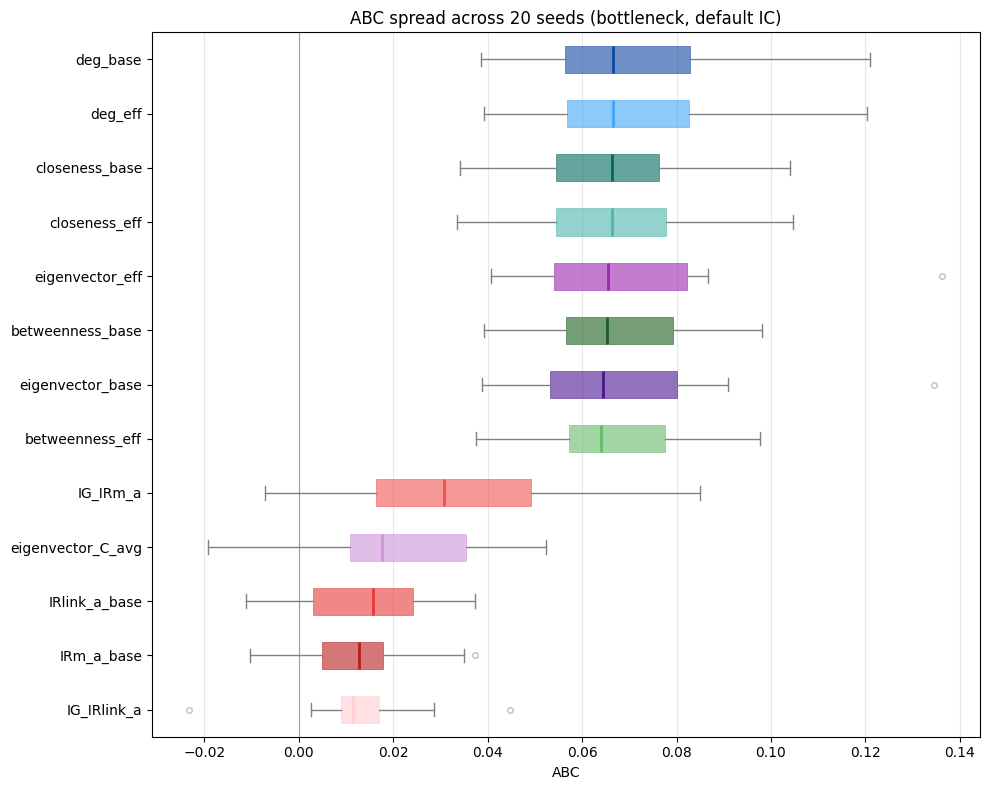

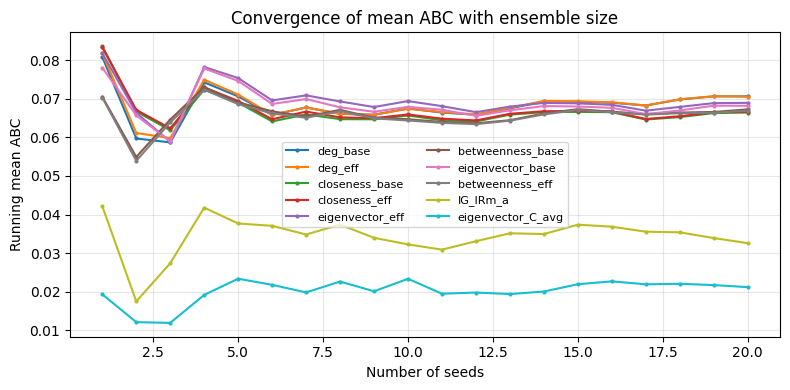

In [ ]:
from kuramoto.plotting import plot_abc_spread_boxplot_h

metrics_sa1a = sorted(sa1a_results[sa1a_seeds[0]].keys())
abc_by_metric = {m: [sa1a_results[s][m]["ABC"] for s in sa1a_seeds] for m in metrics_sa1a}

# ── 1) ABC box plot across seeds ──────────────────────────────────────────────
fig, ax = plot_abc_spread_boxplot_h(
    abc_by_metric,
    title=f"ABC spread across {N_SEEDS_SA1A} seeds (bottleneck, default IC)",
    patch_alpha=0.6,
)
plt.show()

# ── 2) Convergence of running mean ABC for top-K metrics ─────────────────────
TOP_K_CONV = 10
top_metrics = sorted(metrics_sa1a, key=lambda m: np.median(abc_by_metric[m]), reverse=True)[:TOP_K_CONV]

fig, ax = plt.subplots(figsize=(8, 4))
for m in top_metrics:
    vals = np.array(abc_by_metric[m])
    running_mean = np.cumsum(vals) / np.arange(1, len(vals) + 1)
    ax.plot(np.arange(1, len(vals) + 1), running_mean, label=m, marker=".", ms=4)

ax.set_xlabel("Number of seeds")
ax.set_ylabel("Running mean ABC")
ax.set_title("Convergence of mean ABC with ensemble size")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1b) Theta sensitivity
Fix omega distribution (normal, sigma=0.3) and vary the spread of the initial phase distribution theta_0. Uses a normal distribution with increasing sigma.

In [ ]:
sa1b_theta_gammas = [0.5, 1.0, 2.0, 4.0]
seeds = [BASE_SEED + i for i in range(N_SEEDS)]

FIXED_OMEGA_SIGMA = 0.3

sa1b_results: dict[str, dict[int, dict]] = {}
sa1b_base_Rt: dict[str, dict[int, np.ndarray]] = {}
sa1b_labels: dict[str, str] = {}

for theta_gamma in sa1b_theta_gammas:
    case_key = f"theta_gamma={theta_gamma}"
    sa1b_labels[case_key] = f"θγ={theta_gamma}"
    sa1b_results[case_key] = {}
    sa1b_base_Rt[case_key] = {}

    theta_cfg = InitThetaConfig(mode="vonmises", mu=0.0, gamma=theta_gamma)
    omega_cfg = InitOmegaConfig(mode="normal", mu=0.0, sigma=FIXED_OMEGA_SIGMA)

    for seed in seeds:
        print(f"SA1b  {case_key}  seed={seed}")
        cfg = SimulationConfig(
            grid=GridConfig(shape=grid_shape, periodic=False),
            coupling=CouplingConfig(
                mode="spatial",
                components=bottleneck_components_gaussian(),
                group_ids=bottleneck_group_ids(grid_shape),
            ),
            initial_theta=theta_cfg,
            initial_omega=omega_cfg,
            seed=seed,
        )
        sim = build_simulation(config=cfg, rng=np.random.default_rng(seed))

        res = sim.run((0, T_END), dt)
        Rt, _ = order_parameter(res["theta"])
        sa1b_base_Rt[case_key][seed] = np.asarray(Rt)

        sa1b_results[case_key][seed] = evaluate_metric_scores(
            sim, T_END, dt, np.random.default_rng(seed),
            n_random_repeats=n_random_repeats,
            lesion_fracs=lesion_fracs,
            lesion_strength=lesion_strength,
            n_ig_steps=N_IG_STEPS,
            verbose=False,
        )

sa1b_agg = aggregate_scores(sa1b_results)
sa1b_case_names = list(sa1b_results.keys())
print(f"\nDone – {len(sa1b_case_names)} θ-sigma values × {N_SEEDS} seeds.")

SA1b  theta_gamma=0.5  seed=42
Evaluating deg_base...
Evaluating deg_eff...
Evaluating closeness_base...
Evaluating closeness_eff...
Evaluating betweenness_base...
Evaluating betweenness_eff...
Evaluating eigenvector_base...
Evaluating eigenvector_eff...
Evaluating eigenvector_C_avg...
Evaluating IRm_a_base...
Evaluating IRlink_a_base...
Evaluating IG_IRm_a...
Evaluating IG_IRlink_a...
SA1b  theta_gamma=0.5  seed=43
Evaluating deg_base...
Evaluating deg_eff...
Evaluating closeness_base...
Evaluating closeness_eff...
Evaluating betweenness_base...
Evaluating betweenness_eff...
Evaluating eigenvector_base...
Evaluating eigenvector_eff...
Evaluating eigenvector_C_avg...
Evaluating IRm_a_base...
Evaluating IRlink_a_base...
Evaluating IG_IRm_a...
Evaluating IG_IRlink_a...
SA1b  theta_gamma=0.5  seed=44
Evaluating deg_base...
Evaluating deg_eff...
Evaluating closeness_base...
Evaluating closeness_eff...
Evaluating betweenness_base...
Evaluating betweenness_eff...
Evaluating eigenvector_base.

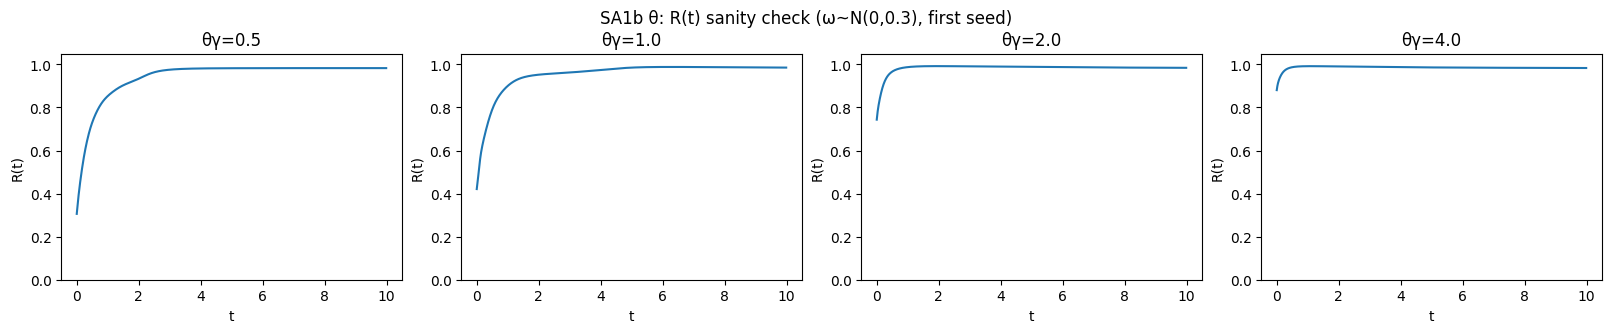

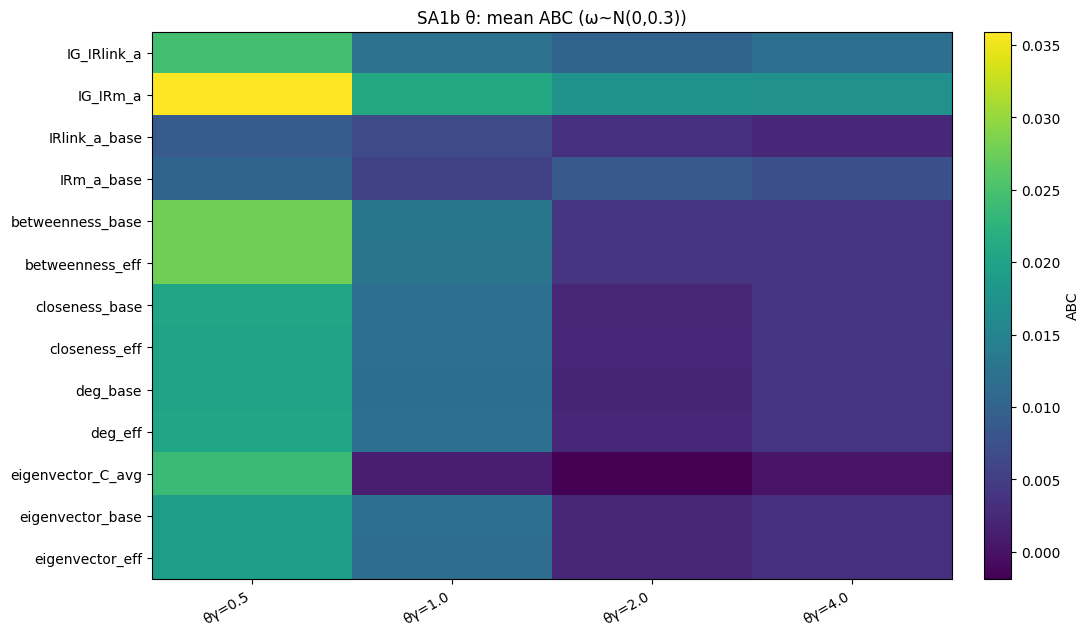

C:\Users\Adam\AppData\Local\Temp\ipykernel_4656\2246094130.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, vert=False, labels=top_m, patch_artist=True)
C:\Users\Adam\AppData\Local\Temp\ipykernel_4656\2246094130.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, vert=False, labels=top_m, patch_artist=True)
C:\Users\Adam\AppData\Local\Temp\ipykernel_4656\2246094130.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, vert=False, labels=top_m, patch_artist=True)
C:\Users\Adam\AppData\Local\Temp\ipykernel_4656\2246094130.py:146: MatplotlibDepre

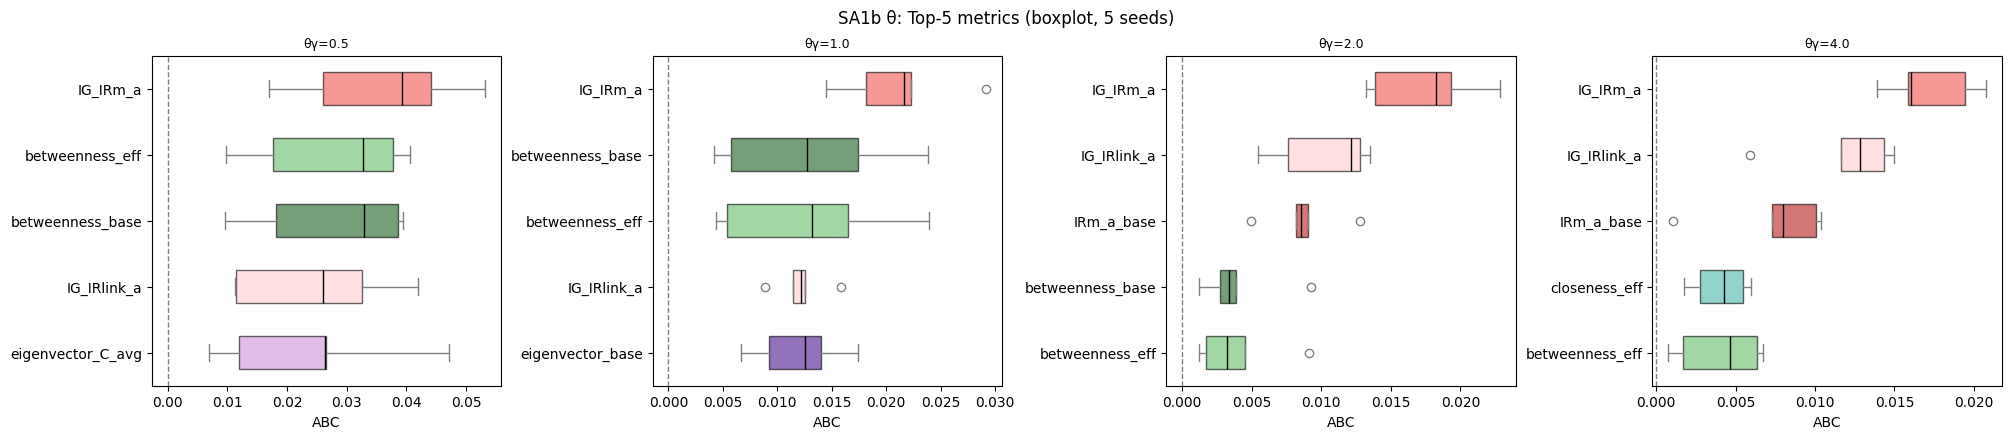

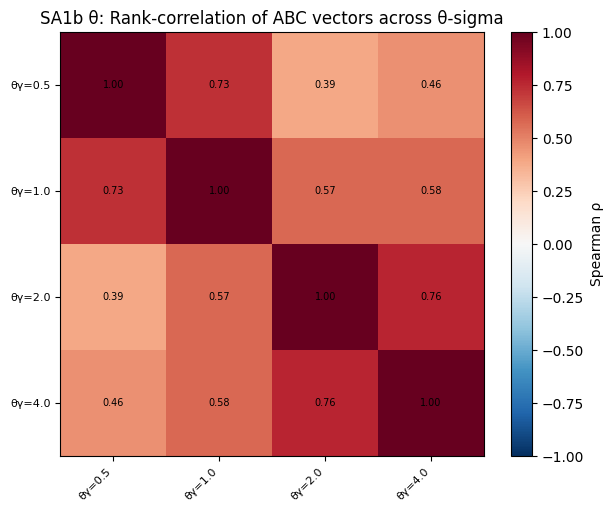

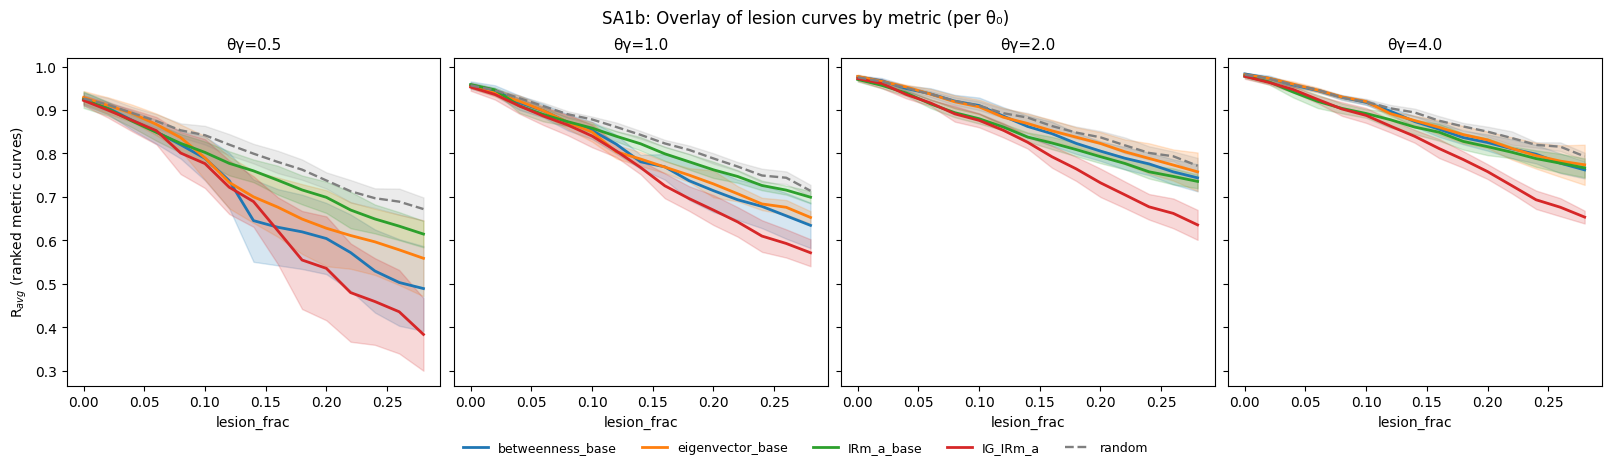

In [85]:
metrics_sa1b = sa1b_agg[sa1b_case_names[0]]["metrics"]

# ── 1) R(t) sanity traces (one seed per theta-sigma) ─────────────────────────
rt_by_case = {c: sa1b_base_Rt[c][seeds[0]] for c in sa1b_case_names}
fig, axs = plot_rt_traces_per_case(
    rt_by_case,
    dt,
    sa1b_labels,
    suptitle=f"SA1b θ: R(t) sanity check (ω~N(0,{FIXED_OMEGA_SIGMA}), first seed)",
)
plt.show()
# ── 2) ABC heatmap: metrics × theta-sigma ────────────────────────────────────
fig, ax = plot_abc_mean_heatmap(
    sa1b_agg,
    sa1b_case_names,
    metrics_sa1b,
    sa1b_labels,
    title=f"SA1b θ: mean ABC (ω~N(0,{FIXED_OMEGA_SIGMA}))",
)
plt.show()
# ── 3) Top-K metrics per theta-sigma ─────────────────────────────────────────
TOP_K = 5
fig, axs_flat = plot_topk_abc_boxplots_h(
    sa1b_results,
    sa1b_agg,
    seeds,
    sa1b_case_names,
    metrics_sa1b,
    sa1b_labels,
    top_k=TOP_K,
    suptitle=f"SA1b θ: Top-{TOP_K} metrics (boxplot, {N_SEEDS} seeds)",
)
plt.show()

# ── 4) Spearman rank-correlation heatmap ─────────────────────────────────────
corr = abc_rank_correlation_matrix(sa1b_agg, sa1b_case_names)
fig, ax = plot_abc_rank_correlation_heatmap(
    corr,
    sa1b_case_names,
    sa1b_labels,
    title="SA1b θ: Rank-correlation of ABC vectors across θ-sigma",
)
plt.show()


# ── 5) Lesion curves for selected metrics ────────────────────────────────────
plot_metrics_sa1b = [
    "betweenness_base", "eigenvector_base", "IRm_a_base", "IG_IRm_a",
]
plot_metrics_sa1b = [m for m in plot_metrics_sa1b if m in metrics_sa1b]
fig, axs = plot_lesion_r_avg_ranked_overlay(
    lesion_fracs,
    sa1b_case_names,
    sa1b_labels,
    sa1b_agg,
    plot_metrics_sa1b,
    suptitle="SA1b: Overlay of lesion curves by metric (per θ₀)",
)
plt.show()

Findings:
Gradient metrics outperform network metrics close to synchronization which makes sense as the gradients are less noisy. Interestingly as initial desynchronization linearized gradients (not integrated) become ineffective, but the integrated R gradient stays in top 3. This also follows expectations and shows the integrated gradients improve robustness.

### 1c) Omega sensitivity
Fix theta distribution (uniform) and vary the spread of the natural frequency distribution omega_0. Uses a normal distribution with increasing sigma.

In [19]:
sa1c_omega_sigmas = [0.1, 0.3, 0.5, 1.0]

FIXED_THETA_MODE = "vonmises"

sa1c_results: dict[str, dict[int, dict]] = {}
sa1c_base_Rt: dict[str, dict[int, np.ndarray]] = {}
sa1c_labels: dict[str, str] = {}

for omega_sig in sa1c_omega_sigmas:
    case_key = f"omega_sig={omega_sig}"
    sa1c_labels[case_key] = f"ωσ={omega_sig}"
    sa1c_results[case_key] = {}
    sa1c_base_Rt[case_key] = {}

    theta_cfg = InitThetaConfig(mode=FIXED_THETA_MODE)
    omega_cfg = InitOmegaConfig(mode="normal", mu=0.0, sigma=omega_sig)

    for seed in seeds:
        print(f"SA1c  {case_key}  seed={seed}")
        cfg = SimulationConfig(
            grid=GridConfig(shape=grid_shape, periodic=False),
            coupling=CouplingConfig(
                mode="spatial",
                components=bottleneck_components_gaussian(),
                group_ids=bottleneck_group_ids(grid_shape),
            ),
            initial_theta=theta_cfg,
            initial_omega=omega_cfg,
            seed=seed,
        )
        sim = build_simulation(config=cfg, rng=np.random.default_rng(seed))

        res = sim.run((0, T_END), dt)
        Rt, _ = order_parameter(res["theta"])
        sa1c_base_Rt[case_key][seed] = np.asarray(Rt)

        sa1c_results[case_key][seed] = evaluate_metric_scores(
            sim, T_END, dt, np.random.default_rng(seed),
            n_random_repeats=n_random_repeats,
            lesion_fracs=lesion_fracs,
            lesion_strength=lesion_strength,
            n_ig_steps=N_IG_STEPS,
            verbose=False,
        )

sa1c_agg = aggregate_scores(sa1c_results)
sa1c_case_names = list(sa1c_results.keys())
print(f"\nDone – {len(sa1c_case_names)} ω-sigma values × {N_SEEDS} seeds.")

SA1c  omega_sig=0.1  seed=42
Evaluating deg_base...
Evaluating deg_eff...
Evaluating closeness_base...
Evaluating closeness_eff...
Evaluating betweenness_base...
Evaluating betweenness_eff...
Evaluating eigenvector_base...
Evaluating eigenvector_eff...
Evaluating eigenvector_C_avg...
Evaluating IRm_a_base...
Evaluating IRlink_a_base...
Evaluating IG_IRm_a...
Evaluating IG_IRlink_a...
SA1c  omega_sig=0.1  seed=43
Evaluating deg_base...
Evaluating deg_eff...
Evaluating closeness_base...
Evaluating closeness_eff...
Evaluating betweenness_base...
Evaluating betweenness_eff...
Evaluating eigenvector_base...
Evaluating eigenvector_eff...
Evaluating eigenvector_C_avg...
Evaluating IRm_a_base...
Evaluating IRlink_a_base...
Evaluating IG_IRm_a...
Evaluating IG_IRlink_a...
SA1c  omega_sig=0.1  seed=44
Evaluating deg_base...
Evaluating deg_eff...
Evaluating closeness_base...
Evaluating closeness_eff...
Evaluating betweenness_base...
Evaluating betweenness_eff...
Evaluating eigenvector_base...
Eva

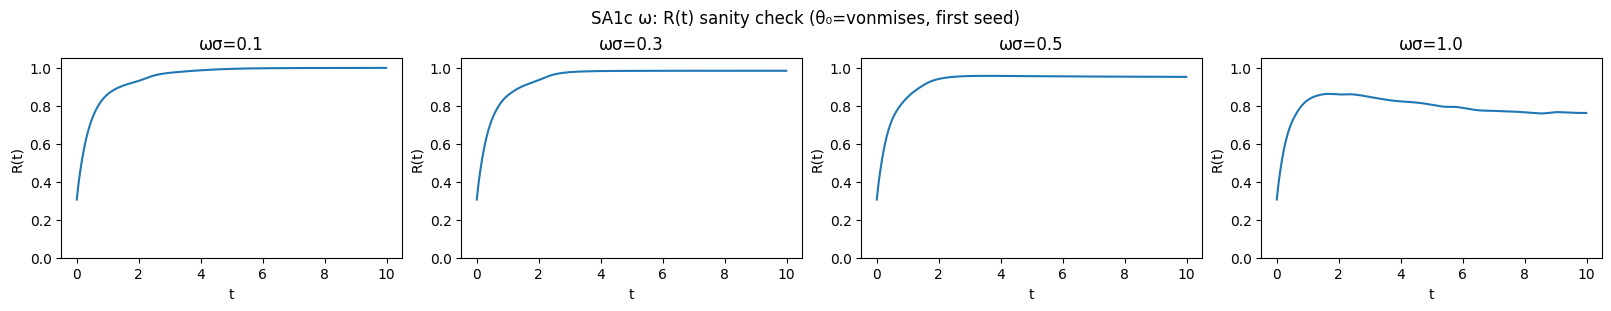

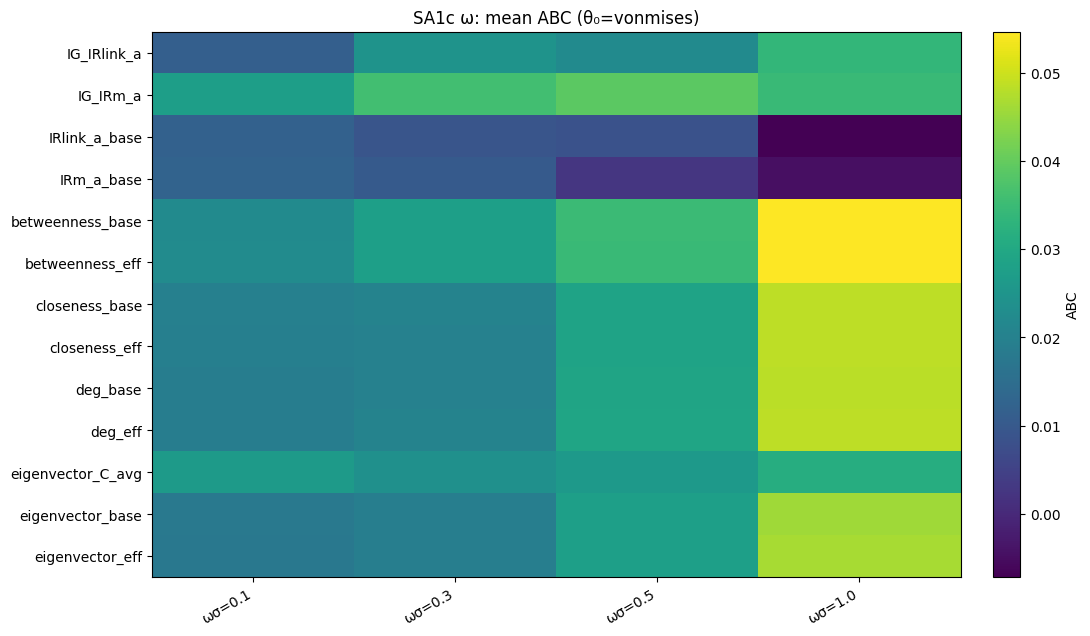

C:\Users\Adam\AppData\Local\Temp\ipykernel_4656\2582745768.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
C:\Users\Adam\AppData\Local\Temp\ipykernel_4656\2582745768.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
C:\Users\Adam\AppData\Local\Temp\ipykernel_4656\2582745768.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
C:\Users\Adam\AppData\Local\Temp\ipykernel_4656\2582745768.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


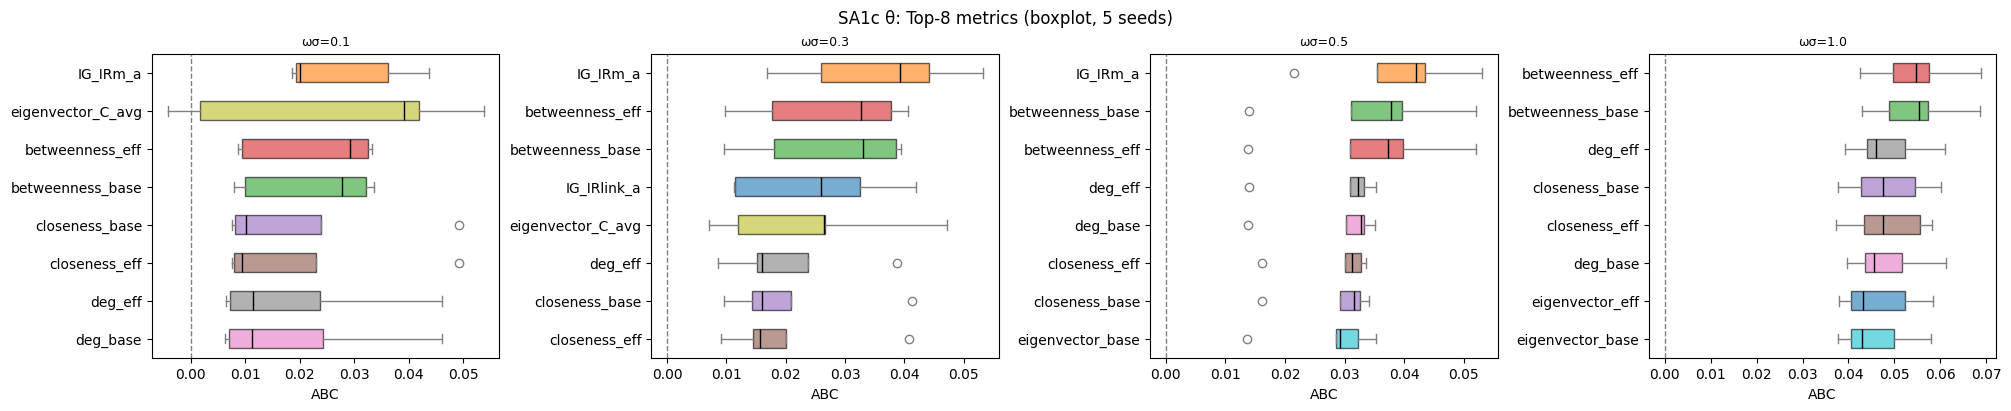

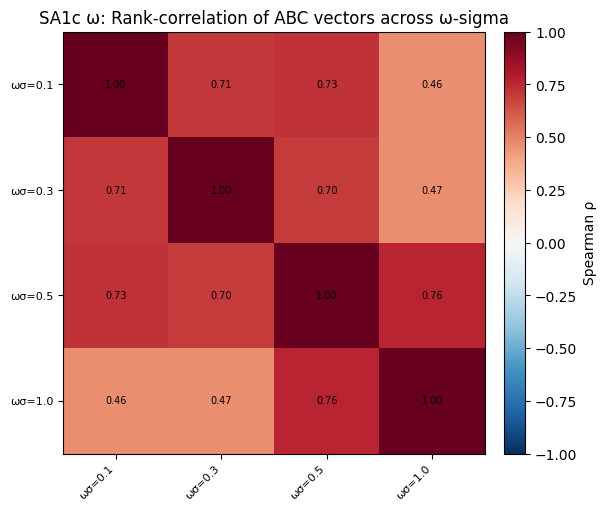

C:\Users\Adam\AppData\Local\Temp\ipykernel_4656\2582745768.py:164: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


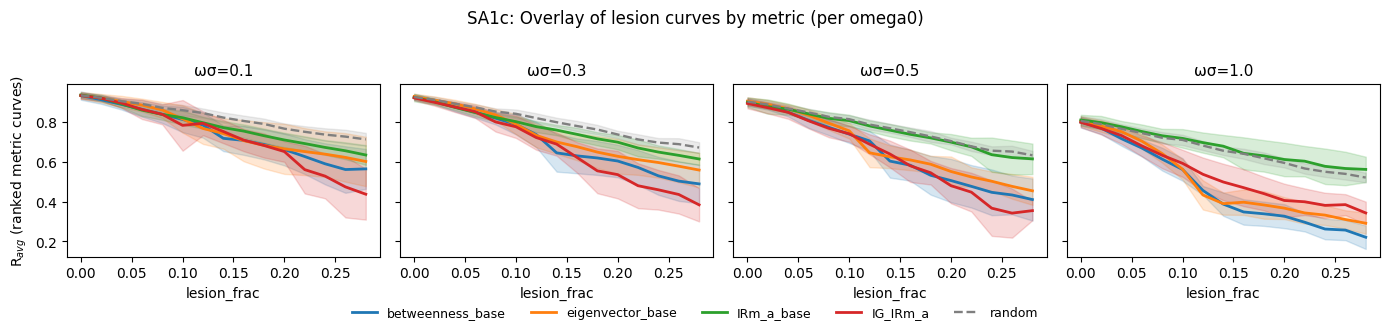

In [47]:
metrics_sa1c = sa1c_agg[sa1c_case_names[0]]["metrics"]

# ── 1) R(t) sanity traces (one seed per omega-sigma) ─────────────────────────
fig, axs = plt.subplots(1, len(sa1c_case_names),
                         figsize=(4 * len(sa1c_case_names), 3),
                         constrained_layout=True)
if len(sa1c_case_names) == 1:
    axs = [axs]
for ax, case_name in zip(axs, sa1c_case_names):
    Rt = sa1c_base_Rt[case_name][seeds[0]]
    ax.plot(np.arange(len(Rt)) * dt, Rt)
    ax.set_title(sa1c_labels[case_name])
    ax.set_xlabel("t")
    ax.set_ylabel("R(t)")
    ax.set_ylim(0, 1.05)
plt.suptitle(f"SA1c ω: R(t) sanity check (θ₀={FIXED_THETA_MODE}, first seed)")
plt.show()


# ── 2) ABC heatmap: metrics × omega-sigma ────────────────────────────────────
heat = np.array(
    [[sa1c_agg[c]["ABC_mean"][m] for c in sa1c_case_names] for m in metrics_sa1c],
    dtype=float,
)
fig, ax = plt.subplots(
    figsize=(1.2 * len(sa1c_case_names) + 6, 0.25 * len(metrics_sa1c) + 3),
    constrained_layout=True,
)
im = ax.imshow(heat, aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(len(sa1c_case_names)))
ax.set_xticklabels([sa1c_labels[c] for c in sa1c_case_names], rotation=30, ha="right")
ax.set_yticks(np.arange(len(metrics_sa1c)))
ax.set_yticklabels(metrics_sa1c)
ax.set_title(f"SA1c ω: mean ABC (θ₀={FIXED_THETA_MODE})")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="ABC")
plt.show()


# ── 3) Top-K metrics per omega-sigma ─────────────────────────────────────────
TOP_K = 8
fig, axs_flat = plt.subplots(1, len(sa1c_case_names),
                              figsize=(5 * len(sa1c_case_names), 4),
                              constrained_layout=True, sharex=False)
if len(sa1c_case_names) == 1:
    axs_flat = [axs_flat]
else:
    axs_flat = list(axs_flat)

# Assign a consistent color to each metric based on metric name
all_metrics = set()
for case_name in sa1c_case_names:
    means = {m: sa1c_agg[case_name]["ABC_mean"][m] for m in metrics_sa1b}
    top_metrics = sorted(means, key=means.__getitem__, reverse=True)[:TOP_K]
    all_metrics.update(top_metrics)
all_metrics = sorted(all_metrics)
cmap = plt.get_cmap("tab10")
metric_to_color = {m: cmap(i % cmap.N) for i, m in enumerate(all_metrics)}

for ax, case_name in zip(axs_flat, sa1c_case_names):
    # Sort by mean ABC descending, take top-K
    means = {m: sa1c_agg[case_name]["ABC_mean"][m] for m in metrics_sa1b}
    top_metrics = sorted(means, key=means.__getitem__, reverse=True)[:TOP_K][::-1]

    # Gather raw per-seed data for each top metric
    data = [
        [sa1c_results[case_name][s][m]["ABC"] for s in seeds]
        for m in top_metrics
    ]

    # Plot, color boxes, add vline at 0
    box = ax.boxplot(
        data, 
        vert=False, 
        labels=top_metrics, 
        patch_artist=True   # Needed for facecolor
    )
    # Add colored boxes for each metric by metric (not rank)
    for patch_i, patch in enumerate(box['boxes']):
        metric_name = top_metrics[patch_i]
        color = metric_to_color.get(metric_name, cmap(patch_i % cmap.N))
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    # Optional: color medians, whiskers, fliers for better style
    for median in box['medians']:
        median.set_color('black')
    for whisker in box['whiskers']:
        whisker.set_color('gray')
    for cap in box['caps']:
        cap.set_color('gray')
    for flier in box['fliers']:
        flier.set_markeredgecolor('gray')
    # Add vertical line at x=0
    ax.axvline(0, color='gray', linestyle='--', linewidth=1, zorder=0)
    ax.set_title(sa1c_labels[case_name], fontsize=9)
    ax.set_xlabel("ABC")

plt.suptitle(f"SA1c θ: Top-{TOP_K} metrics (boxplot, {N_SEEDS} seeds)")
plt.show()


# ── 4) Spearman rank-correlation heatmap ─────────────────────────────────────
corr = rank_correlation_matrix(sa1c_agg, sa1c_case_names)
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ticks = np.arange(len(sa1c_case_names))
ax.set_xticks(ticks)
ax.set_xticklabels([sa1c_labels[c] for c in sa1c_case_names], rotation=45, ha="right", fontsize=8)
ax.set_yticks(ticks)
ax.set_yticklabels([sa1c_labels[c] for c in sa1c_case_names], fontsize=8)
for i in range(len(sa1c_case_names)):
    for j in range(len(sa1c_case_names)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman ρ")
ax.set_title("SA1c ω: Rank-correlation of ABC vectors across ω-sigma")
plt.show()


# ── 5) Lesion curves for selected metrics ────────────────────────────────────
plot_metrics_sa1c = [
    "betweenness_base", "eigenvector_base", "IRm_a_base", "IG_IRm_a",
]
plot_metrics_sa1c = [m for m in plot_metrics_sa1c if m in metrics_sa1c]

metric_colors = plt.get_cmap("tab10")
ncols_lc = len(sa1c_case_names)

# Always return 2D array of axes for consistent indexing
fig, axs = plt.subplots(
    1, ncols_lc,
    figsize=(3.5 * ncols_lc, 3),
    constrained_layout=True, sharex=True, sharey=True,
)
if ncols_lc == 1:
    axs = np.array([axs])  # axs will be 1D array with 1 element

for c, case_name in enumerate(sa1c_case_names):
    # For a single column, axs[0, c] fails; just use axs[c] for generality
    ax = axs.flat[c]
    x = lesion_fracs

    # Overlay all metrics as separate lines
    for i, metric in enumerate(plot_metrics_sa1c):
        y = sa1c_agg[case_name]["R_avg_ranked_mean"][metric]
        yerr = sa1c_agg[case_name]["R_avg_ranked_std"][metric]
        color = metric_colors(i)
        ax.plot(x, y, label=metric, color=color, lw=2)
        ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.18)

    # Plot random baseline (gray, dashed, shared style for all metrics, no legend)
    y0 = sa1c_agg[case_name]["R_avg_random_mean"][plot_metrics_sa1c[0]]
    y0err = sa1c_agg[case_name]["R_avg_random_std"][plot_metrics_sa1c[0]]
    ax.plot(x, y0, label="random", color="tab:gray", linestyle="--", lw=1.7)
    ax.fill_between(x, y0 - y0err, y0 + y0err, color="tab:gray", alpha=0.15)
    
    ax.set_title(sa1c_labels[case_name], fontsize=11)
    if c == 0:
        ax.set_ylabel(r"R$_{avg}$ (ranked metric curves)")
    ax.set_xlabel("lesion_frac")

# Legend below all subplots for compactness & clarity
handles, labels = axs.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=min(len(handles), 5), bbox_to_anchor=(0.5, -0.05), fontsize=9, frameon=False)
plt.suptitle("SA1c: Overlay of lesion curves by metric (per omega0)", y=1.02)
plt.tight_layout()
plt.show()

Findings:
gradient based methods are again most effective with narrow omega0 distributions, but lose effectiveness with bigger gaps. IGRm_a is more robust to this initialization and has highest score until omega = 0.5, but at the widest distribution it isnt even in top 8. The graients are likely too disordered when the oscillator frequencies are too dispersed. The ABCs are particularly large at this wide distribution - the possibility that the progressive lesioning and ABC score are biased also cannot be discarded.

### 2) Coupling strength sensitivity
Run lesion studies on bottleneck case with varying coupling strength. Compare metric scores across cases.

In [21]:
sa2_k_factors = [0.25, 0.5, 1.0, 2.0, 4.0]

sa2_results: dict[str, dict[int, dict]] = {}
sa2_base_Rt: dict[str, dict[int, np.ndarray]] = {}
sa2_labels: dict[str, str] = {}

for kf in sa2_k_factors:
    case_key = f"k={kf}"
    sa2_labels[case_key] = f"K×{kf}"
    sa2_results[case_key] = {}
    sa2_base_Rt[case_key] = {}

    for seed in seeds:
        print(f"SA2  {case_key}  seed={seed}")
        cfg = SimulationConfig(
            grid=GridConfig(shape=grid_shape, periodic=False),
            coupling=CouplingConfig(
                mode="spatial",
                components=bottleneck_components_gaussian(k_factor=kf),
                group_ids=bottleneck_group_ids(grid_shape),
            ),
            initial_theta=InitThetaConfig(mode="vonmises"),
            initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
            seed=seed,
        )
        sim = build_simulation(config=cfg, rng=np.random.default_rng(seed))

        res = sim.run((0, T_END), dt)
        Rt, _ = order_parameter(res["theta"])
        sa2_base_Rt[case_key][seed] = np.asarray(Rt)

        sa2_results[case_key][seed] = evaluate_metric_scores(
            sim, T_END, dt, np.random.default_rng(seed),
            n_random_repeats=n_random_repeats,
            lesion_fracs=lesion_fracs,
            lesion_strength=lesion_strength,
            n_ig_steps=N_IG_STEPS,
            verbose=False,
        )

sa2_agg = aggregate_scores(sa2_results)
sa2_case_names = list(sa2_results.keys())
print(f"\nDone – {len(sa2_case_names)} k_factors × {N_SEEDS} seeds.")

SA2  k=0.25  seed=42
Evaluating deg_base...
Evaluating deg_eff...
Evaluating closeness_base...
Evaluating closeness_eff...
Evaluating betweenness_base...
Evaluating betweenness_eff...
Evaluating eigenvector_base...
Evaluating eigenvector_eff...
Evaluating eigenvector_C_avg...
Evaluating IRm_a_base...
Evaluating IRlink_a_base...
Evaluating IG_IRm_a...
Evaluating IG_IRlink_a...
SA2  k=0.25  seed=43
Evaluating deg_base...
Evaluating deg_eff...
Evaluating closeness_base...
Evaluating closeness_eff...
Evaluating betweenness_base...
Evaluating betweenness_eff...
Evaluating eigenvector_base...
Evaluating eigenvector_eff...
Evaluating eigenvector_C_avg...
Evaluating IRm_a_base...
Evaluating IRlink_a_base...
Evaluating IG_IRm_a...
Evaluating IG_IRlink_a...
SA2  k=0.25  seed=44
Evaluating deg_base...
Evaluating deg_eff...
Evaluating closeness_base...
Evaluating closeness_eff...
Evaluating betweenness_base...
Evaluating betweenness_eff...
Evaluating eigenvector_base...
Evaluating eigenvector_eff.

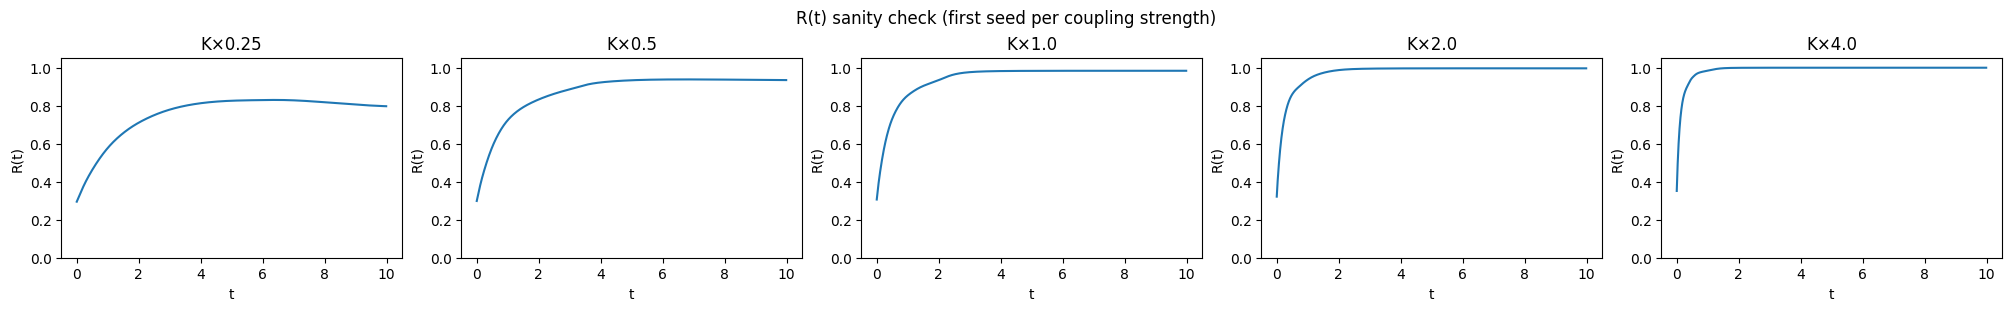

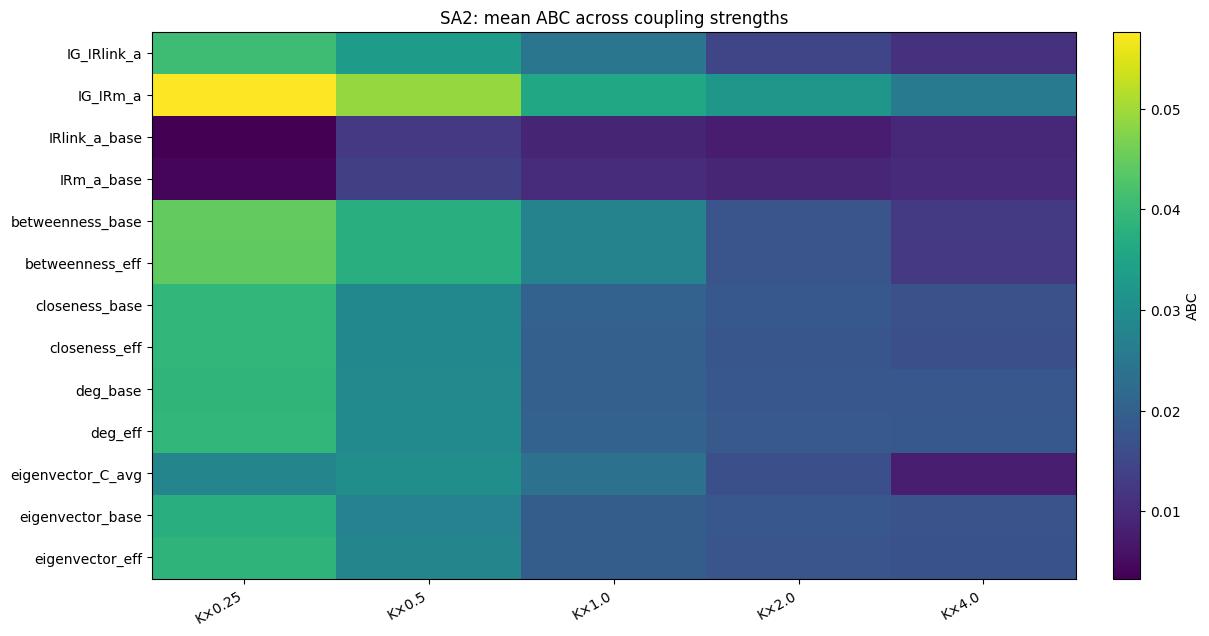

C:\Users\Adam\AppData\Local\Temp\ipykernel_4656\2064259136.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
C:\Users\Adam\AppData\Local\Temp\ipykernel_4656\2064259136.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
C:\Users\Adam\AppData\Local\Temp\ipykernel_4656\2064259136.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
C:\Users\Adam\AppData\Local\Temp\ipykernel_4656\2064259136.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


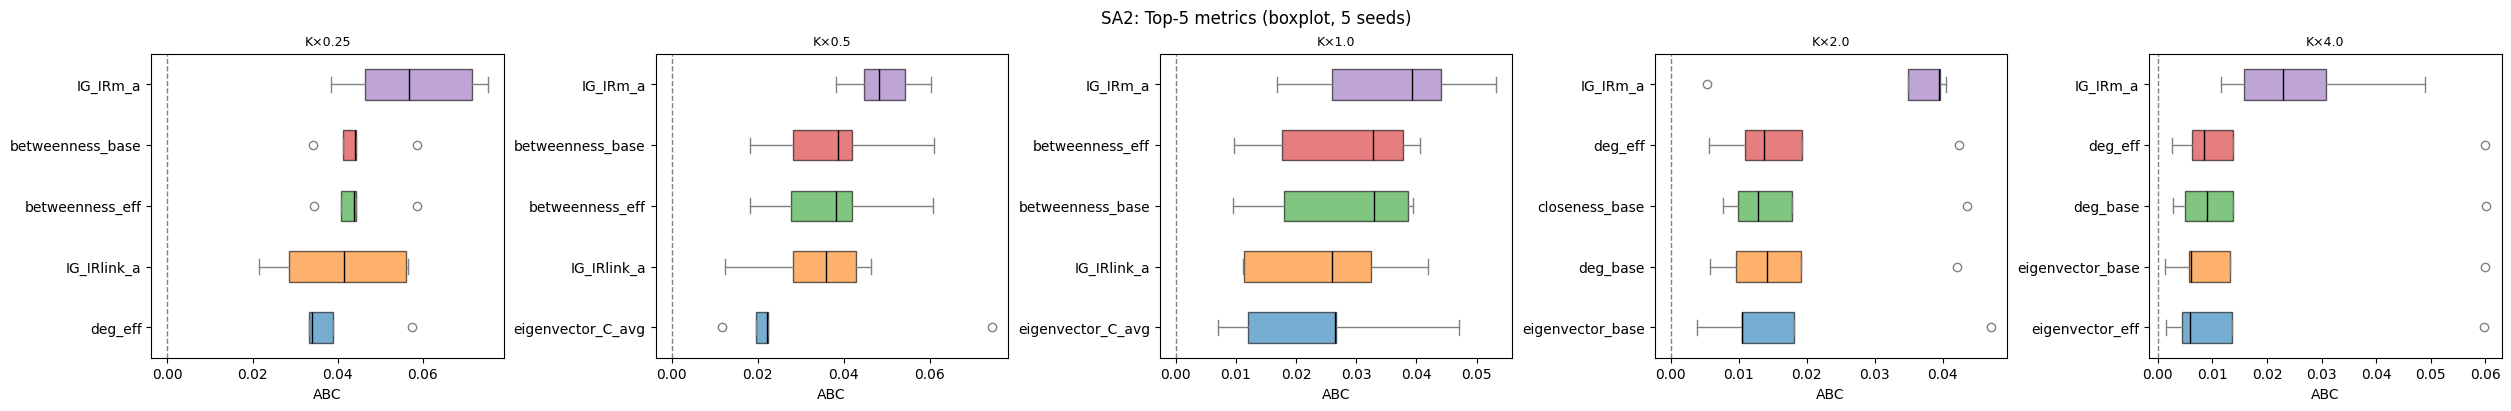

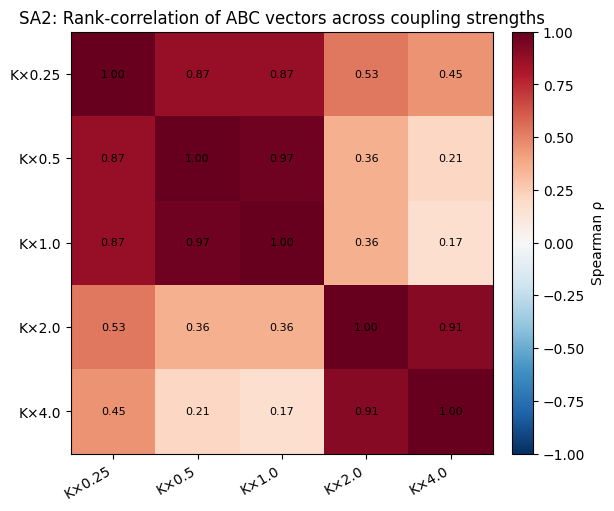

C:\Users\Adam\AppData\Local\Temp\ipykernel_4656\2064259136.py:158: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


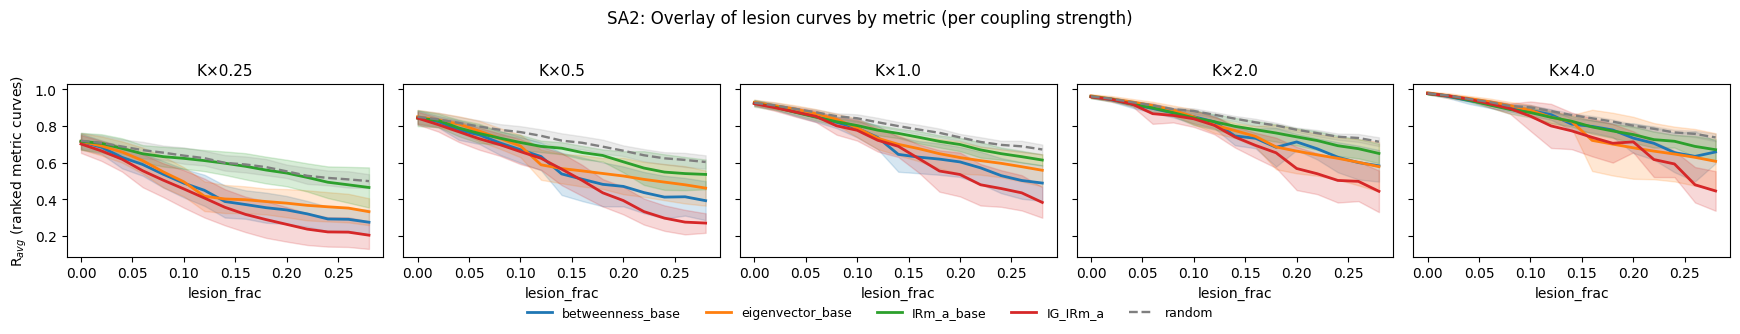

In [ ]:
metrics_sa2 = sa2_agg[sa2_case_names[0]]["metrics"]

# ── 1) R(t) sanity traces (one seed per k_factor) ────────────────────────────
fig, axs = plt.subplots(1, len(sa2_case_names),
                         figsize=(4 * len(sa2_case_names), 3),
                         constrained_layout=True)
if len(sa2_case_names) == 1:
    axs = [axs]
for ax, case_name in zip(axs, sa2_case_names):
    Rt = sa2_base_Rt[case_name][seeds[0]]
    ax.plot(np.arange(len(Rt)) * dt, Rt)
    ax.set_title(sa2_labels[case_name])
    ax.set_xlabel("t")
    ax.set_ylabel("R(t)")
    ax.set_ylim(0, 1.05)
plt.suptitle("R(t) sanity check (first seed per coupling strength)")
plt.show()


# ── 2) ABC heatmap: metrics × k_factors ──────────────────────────────────────
heat = np.array(
    [[sa2_agg[c]["ABC_mean"][m] for c in sa2_case_names] for m in metrics_sa2],
    dtype=float,
)
fig, ax = plt.subplots(
    figsize=(1.2 * len(sa2_case_names) + 6, 0.25 * len(metrics_sa2) + 3),
    constrained_layout=True,
)
im = ax.imshow(heat, aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(len(sa2_case_names)))
ax.set_xticklabels([sa2_labels[c] for c in sa2_case_names], rotation=30, ha="right")
ax.set_yticks(np.arange(len(metrics_sa2)))
ax.set_yticklabels(metrics_sa2)
ax.set_title("SA2: mean ABC across coupling strengths")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="ABC")
plt.show()


# ── 3) Top-K metrics per k_factor ────────────────────────────────────────────
TOP_K = 5
fig, axs_flat = plt.subplots(1, len(sa2_case_names),
                              figsize=(5 * len(sa2_case_names), 4),
                              constrained_layout=True, sharex=False)
if len(sa2_case_names) == 1:
    axs_flat = [axs_flat]
else:
    axs_flat = list(axs_flat)

for ax, case_name in zip(axs_flat, sa2_case_names):
    # Sort by mean ABC descending, take top-K
    means = {m: sa2_agg[case_name]["ABC_mean"][m] for m in metrics_sa1b}
    top_metrics = sorted(means, key=means.__getitem__, reverse=True)[:TOP_K][::-1]

    # Gather raw per-seed data for each top metric
    data = [
        [sa2_results[case_name][s][m]["ABC"] for s in seeds]
        for m in top_metrics
    ]

    # Plot, color boxes, add vline at 0
    box = ax.boxplot(
        data, 
        vert=False, 
        labels=top_metrics, 
        patch_artist=True   # Needed for facecolor
    )
    # Add colored boxes for each metric
    cmap = plt.get_cmap("tab10")
    for patch_i, patch in enumerate(box['boxes']):
        color = cmap(patch_i % cmap.N)
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    # Optional: color medians, whiskers, fliers for better style
    for median in box['medians']:
        median.set_color('black')
    for whisker in box['whiskers']:
        whisker.set_color('gray')
    for cap in box['caps']:
        cap.set_color('gray')
    for flier in box['fliers']:
        flier.set_markeredgecolor('gray')
    # Add vertical line at x=0
    ax.axvline(0, color='gray', linestyle='--', linewidth=1, zorder=0)
    ax.set_title(sa2_labels[case_name], fontsize=9)
    ax.set_xlabel("ABC")

plt.suptitle(f"SA2: Top-{TOP_K} metrics (boxplot, {N_SEEDS} seeds)")
plt.show()


# ── 4) Spearman rank-correlation heatmap ─────────────────────────────────────
corr = rank_correlation_matrix(sa2_agg, sa2_case_names)
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ticks = np.arange(len(sa2_case_names))
ax.set_xticks(ticks)
ax.set_xticklabels([sa2_labels[c] for c in sa2_case_names], rotation=30, ha="right")
ax.set_yticks(ticks)
ax.set_yticklabels([sa2_labels[c] for c in sa2_case_names])
for i in range(len(sa2_case_names)):
    for j in range(len(sa2_case_names)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman ρ")
ax.set_title("SA2: Rank-correlation of ABC vectors across coupling strengths")
plt.show()


# ── 5) Lesion curves for selected metrics ────────────────────────────────────
plot_metrics_sa2 = [
    "betweenness_base", "eigenvector_base", "IRm_a_base", "IG_IRm_a",
]
plot_metrics_sa2 = [m for m in plot_metrics_sa2 if m in metrics_sa2]

metric_colors = plt.get_cmap("tab10")
n_metrics = len(plot_metrics_sa2)
ncols_lc = len(sa2_case_names)

# Always return 2D array of axes for consistent indexing
fig, axs = plt.subplots(
    1, ncols_lc,
    figsize=(3.5 * ncols_lc, 3),
    constrained_layout=True, sharex=True, sharey=True,
)
if ncols_lc == 1:
    axs = np.array([axs])  # axs will be 1D array with 1 element

for c, case_name in enumerate(sa2_case_names):
    # For a single column, axs[0, c] fails; just use axs[c] for generality
    ax = axs.flat[c]
    x = lesion_fracs

    # Overlay all metrics as separate lines
    for i, metric in enumerate(plot_metrics_sa2):
        y = sa2_agg[case_name]["R_avg_ranked_mean"][metric]
        yerr = sa2_agg[case_name]["R_avg_ranked_std"][metric]
        color = metric_colors(i)
        ax.plot(x, y, label=metric, color=color, lw=2)
        ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.18)

    # Plot random baseline (gray, dashed, shared style for all metrics, no legend)
    y0 = sa2_agg[case_name]["R_avg_random_mean"][plot_metrics_sa2[0]]
    y0err = sa2_agg[case_name]["R_avg_random_std"][plot_metrics_sa2[0]]
    ax.plot(x, y0, label="random", color="tab:gray", linestyle="--", lw=1.7)
    ax.fill_between(x, y0 - y0err, y0 + y0err, color="tab:gray", alpha=0.15)
    
    ax.set_title(sa2_labels[case_name], fontsize=11)
    if c == 0:
        ax.set_ylabel(r"R$_{avg}$ (ranked metric curves)")
    ax.set_xlabel("lesion_frac")

# Legend below all subplots for compactness & clarity
handles, labels = axs.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=min(len(handles), 5), bbox_to_anchor=(0.5, -0.05), fontsize=9, frameon=False)
plt.suptitle("SA2: Overlay of lesion curves by metric (per coupling strength)", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
plot_metrics_sa2 = [
    "betweenness_base", "eigenvector_base", "IRm_a_base", "IG_IRm_a",
]
plot_metrics_sa2 = [m for m in plot_metrics_sa2 if m in metrics_sa2]

nrows_lc = len(plot_metrics_sa2)
ncols_lc = len(sa2_case_names)
fig, axs = plt.subplots(
    nrows_lc, ncols_lc,
    figsize=(3.5 * ncols_lc, 2.6 * nrows_lc),
    constrained_layout=True, sharex=True, sharey=True,
)
if nrows_lc == 1:
    axs = np.expand_dims(axs, axis=0)
if ncols_lc == 1:
    axs = np.expand_dims(axs, axis=1)

for r, metric in enumerate(plot_metrics_sa2):
    for c, case_name in enumerate(sa2_case_names):
        ax = axs[r, c]
        x = lesion_fracs
        y = sa2_agg[case_name]["R_avg_ranked_mean"][metric]
        yerr = sa2_agg[case_name]["R_avg_ranked_std"][metric]
        ax.plot(x, y, label="ranked", color="tab:blue")
        ax.fill_between(x, y - yerr, y + yerr, color="tab:blue", alpha=0.2)

        y0 = sa2_agg[case_name]["R_avg_random_mean"][metric]
        y0err = sa2_agg[case_name]["R_avg_random_std"][metric]
        ax.plot(x, y0, label="random", color="tab:gray")
        ax.fill_between(x, y0 - y0err, y0 + y0err, color="tab:gray", alpha=0.2)

        if r == 0:
            ax.set_title(sa2_labels[case_name])
        if c == 0:
            ax.set_ylabel(f"{metric}\nR_avg")
        if r == nrows_lc - 1:
            ax.set_xlabel("lesion_frac")

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.suptitle("SA2: Lesion curves across coupling strengths")
plt.show()

### 3) Structural sensitivity
Compare bottleneck and unstructured network.

NameError: name 'case_names' is not defined